In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"

# I) Loading Adapter weights

In [31]:
from peft import set_peft_model_state_dict
from huggingface_hub import hf_hub_download
def load_adapter(huggingface_repo):
    model,tokenizer=FastLanguageModel.from_pretrained(
        model_name="unsloth/gemma-3-270m-it",
        max_seq_length=2048,
        load_in_4bit=True,
    )
    model=FastLanguageModel.get_peft_model(
        model,
        r=16,
        target_modules=["q_proj","k_proj","v_proj","o_proj",
                       "up_proj","down_proj","gate_proj"],
        lora_alpha=32,
        lora_dropout=0,
        use_rslora=False,
    )
    try:
        model_weights=hf_hub_download(
         repo_id=f"Srishtik/{huggingface_repo}",
         filename="adapter_model.safetensors"
        )
    except:
        model_weights=hf_hub_download(
         repo_id=f"Srishtik/{huggingface_repo}",
         filename="adapter_model.bin"
        )
    from safetensors.torch import load_file
    model_weights=load_file(model_weights)
    set_peft_model_state_dict(model,model_weights)
    return model

In [32]:
full_model=load_adapter("gemma-ag-news-finetuned_on_50K_samples")
model_1=load_adapter("gemma3-270m-agnews-25k")
model_2=load_adapter("gemma3-270m-agnews-25k-1")

==((====))==  Unsloth 2026.6.1: Fast Gemma3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.6.1: Fast Gemma3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.6.1: Fast Gemma3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

# II) Extract Model weight deltas

In [33]:
def extract_lora_deltas(model):
    deltas={}

    for name,module in model.named_modules():
        if hasattr(module,"lora_A") and hasattr(module,"lora_B"):
            for adapter_name in module.lora_A.keys():
                A=module.lora_A[adapter_name].weight.detach().cpu()
                B=module.lora_B[adapter_name].weight.detach().cpu()
                delta=B@A
                deltas[name]=delta

    return deltas

In [34]:
full_model_deltas=extract_lora_deltas(full_model)
model_1_deltas=extract_lora_deltas(model_1)
model_2_deltas=extract_lora_deltas(model_2)

# III) Comparing the Model weights

## 1) Frobenius Norm

In [35]:
def frobenius_norm(deltas):
    return deltas.norm(p="fro").item()

### 1.1) Full Model Norms


In [36]:
full_model_norms={}
for layer_name,delta in full_model_deltas.items():
    full_model_norms[layer_name]=frobenius_norm(delta)

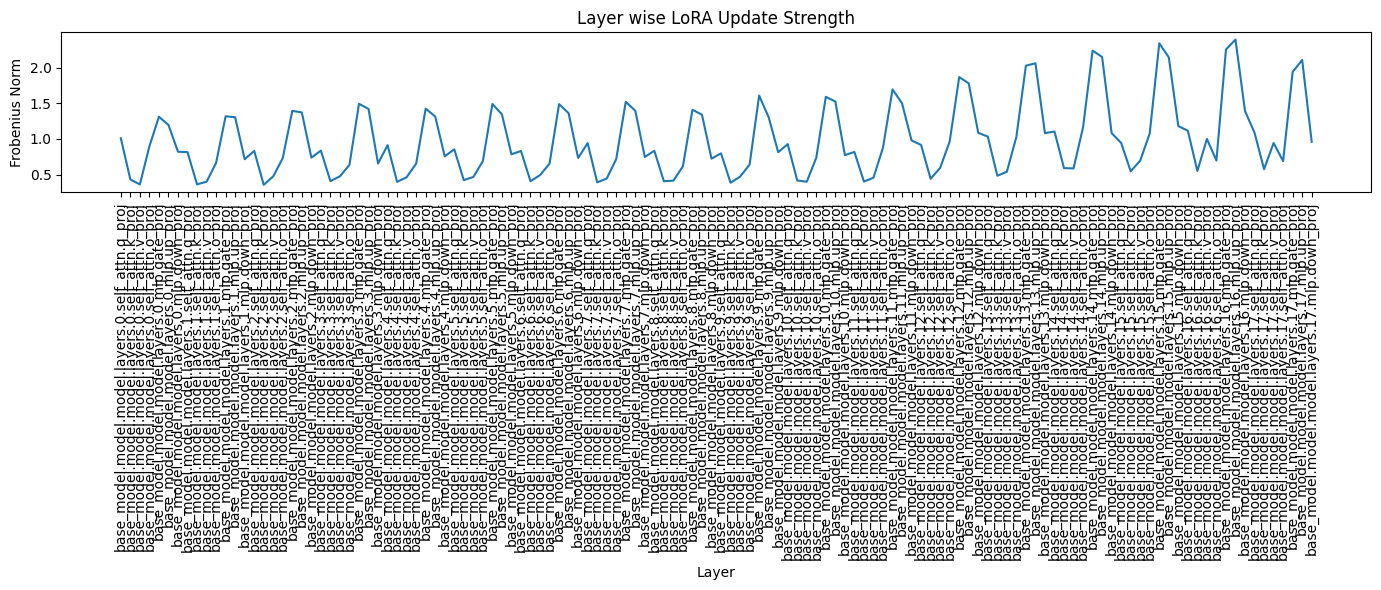

In [37]:
import matplotlib.pyplot as plt

layers=list(full_model_norms.keys())
values=list(full_model_norms.values())

plt.figure(figsize=(14,6))
plt.plot(range(len(values)),values)
plt.xticks(range(len(values)),layers,rotation=90)
plt.ylabel("Frobenius Norm")
plt.xlabel("Layer")
plt.title("Layer wise LoRA Update Strength")
plt.tight_layout()
plt.show()

### 1.2) Model_1 norms

In [38]:
model_1_norms={}
for layer_name,delta in model_1_deltas.items():
    model_1_norms[layer_name]=frobenius_norm(delta)

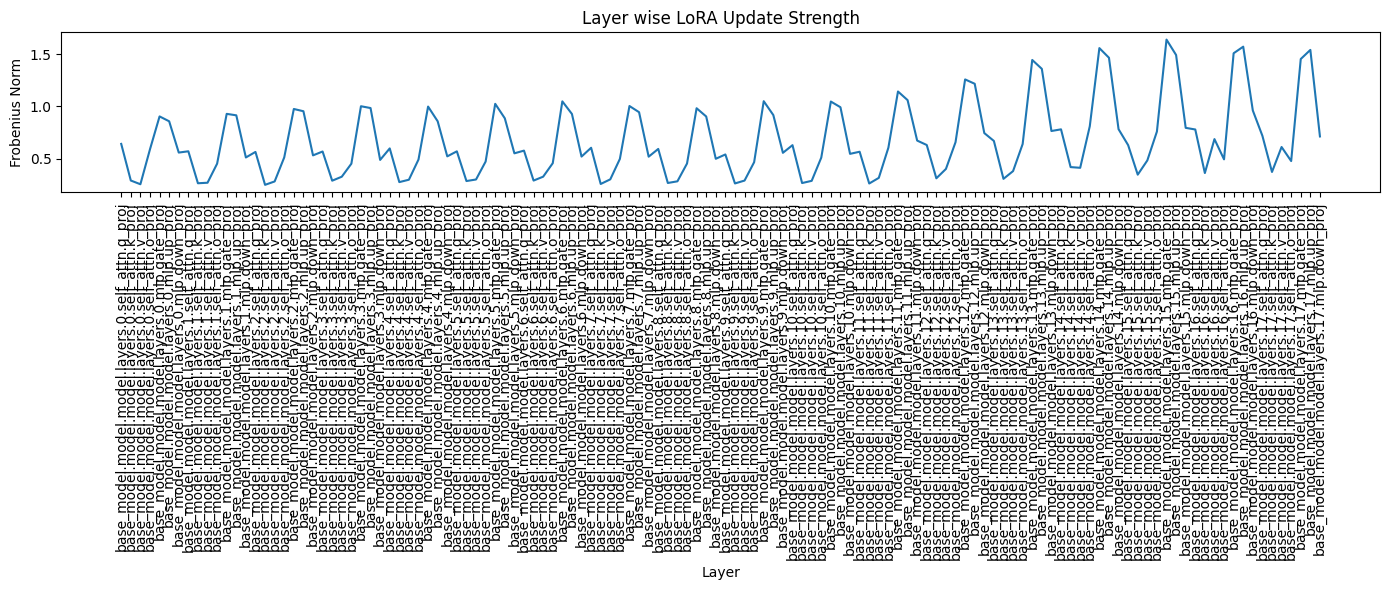

In [39]:
import matplotlib.pyplot as plt

layers=list(model_1_norms.keys())
values=list(model_1_norms.values())

plt.figure(figsize=(14,6))
plt.plot(range(len(values)),values)
plt.xticks(range(len(values)),layers,rotation=90)
plt.ylabel("Frobenius Norm")
plt.xlabel("Layer")
plt.title("Layer wise LoRA Update Strength")
plt.tight_layout()
plt.show()

### 1.3) Model_2 Norms

In [40]:
model_2_norms={}
for layer_name,delta in model_2_deltas.items():
    model_2_norms[layer_name]=frobenius_norm(delta)

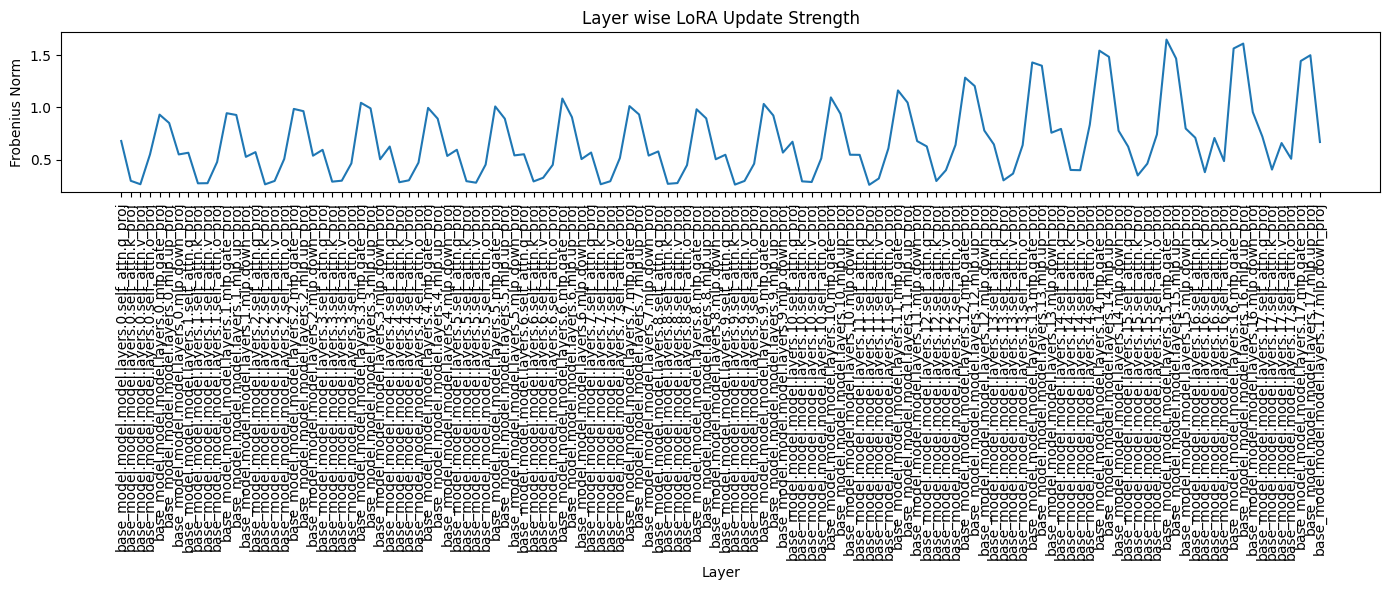

In [41]:
import matplotlib.pyplot as plt

layers=list(model_2_norms.keys())
values=list(model_2_norms.values())

plt.figure(figsize=(14,6))
plt.plot(range(len(values)),values)
plt.xticks(range(len(values)),layers,rotation=90)
plt.ylabel("Frobenius Norm")
plt.xlabel("Layer")
plt.title("Layer wise LoRA Update Strength")
plt.tight_layout()
plt.show()

## 2) Cosine Similarity

In [42]:
import torch
import pandas as pd

import torch
import pandas as pd


def true_cosine_similarity(delta1, delta2):

    v1 = delta1.flatten().to(torch.float64)
    v2 = delta2.flatten().to(torch.float64)

    dot_product = torch.dot(v1, v2)

    norm1 = torch.norm(v1)
    norm2 = torch.norm(v2)

    cosine = dot_product / (norm1 * norm2)

    return cosine.item()


def compute_all_layer_cosines(adapter1_deltas, adapter2_deltas):

    results = []

    common_layers = set(adapter1_deltas.keys()) & set(adapter2_deltas.keys())

    for layer_name in sorted(common_layers):

        delta1 = adapter1_deltas[layer_name]
        delta2 = adapter2_deltas[layer_name]

        cosine = true_cosine_similarity(delta1, delta2)

        results.append({
            "layer": layer_name,
            "cosine_similarity": cosine
        })

    return pd.DataFrame(results)


# Compute similarities
cosine_df1 = compute_all_layer_cosines(
    full_model_deltas,
    model_1_deltas
)
cosine_df2=compute_all_layer_cosines(
    full_model_deltas,
    model_2_deltas
)
cosine_df3=compute_all_layer_cosines(
    model_1_deltas,
    model_2_deltas
)

### 2.1) Between Full_Model and Model_1

In [43]:
print(cosine_df1.to_string(index=False))

                                            layer  cosine_similarity
    base_model.model.model.layers.0.mlp.down_proj           0.446235
    base_model.model.model.layers.0.mlp.gate_proj           0.495869
      base_model.model.model.layers.0.mlp.up_proj           0.498198
 base_model.model.model.layers.0.self_attn.k_proj           0.593936
 base_model.model.model.layers.0.self_attn.o_proj           0.510827
 base_model.model.model.layers.0.self_attn.q_proj           0.557673
 base_model.model.model.layers.0.self_attn.v_proj           0.727963
    base_model.model.model.layers.1.mlp.down_proj           0.422347
    base_model.model.model.layers.1.mlp.gate_proj           0.507339
      base_model.model.model.layers.1.mlp.up_proj           0.528676
 base_model.model.model.layers.1.self_attn.k_proj           0.528345
 base_model.model.model.layers.1.self_attn.o_proj           0.447758
 base_model.model.model.layers.1.self_attn.q_proj           0.492786
 base_model.model.model.layers.1.s

### 2.2) Between Full_Model and Model_2

In [44]:
print(cosine_df2.to_string(index=False))

                                            layer  cosine_similarity
    base_model.model.model.layers.0.mlp.down_proj           0.440438
    base_model.model.model.layers.0.mlp.gate_proj           0.501330
      base_model.model.model.layers.0.mlp.up_proj           0.501978
 base_model.model.model.layers.0.self_attn.k_proj           0.572413
 base_model.model.model.layers.0.self_attn.o_proj           0.501324
 base_model.model.model.layers.0.self_attn.q_proj           0.556966
 base_model.model.model.layers.0.self_attn.v_proj           0.725279
    base_model.model.model.layers.1.mlp.down_proj           0.418965
    base_model.model.model.layers.1.mlp.gate_proj           0.510625
      base_model.model.model.layers.1.mlp.up_proj           0.523216
 base_model.model.model.layers.1.self_attn.k_proj           0.520730
 base_model.model.model.layers.1.self_attn.o_proj           0.442287
 base_model.model.model.layers.1.self_attn.q_proj           0.480817
 base_model.model.model.layers.1.s

### 2.3) Between Model_1 and Model_2

In [45]:
print(cosine_df3.to_string(index=False))

                                            layer  cosine_similarity
    base_model.model.model.layers.0.mlp.down_proj           0.326266
    base_model.model.model.layers.0.mlp.gate_proj           0.329142
      base_model.model.model.layers.0.mlp.up_proj           0.331807
 base_model.model.model.layers.0.self_attn.k_proj           0.447981
 base_model.model.model.layers.0.self_attn.o_proj           0.455857
 base_model.model.model.layers.0.self_attn.q_proj           0.477248
 base_model.model.model.layers.0.self_attn.v_proj           0.659318
    base_model.model.model.layers.1.mlp.down_proj           0.286415
    base_model.model.model.layers.1.mlp.gate_proj           0.334352
      base_model.model.model.layers.1.mlp.up_proj           0.336176
 base_model.model.model.layers.1.self_attn.k_proj           0.354788
 base_model.model.model.layers.1.self_attn.o_proj           0.297219
 base_model.model.model.layers.1.self_attn.q_proj           0.324168
 base_model.model.model.layers.1.s

## 3) Singular Values

In [46]:
import numpy as np
import torch

def singular_values(deltas):
    s=torch.linalg.svdvals(deltas)
    return s.numpy()

In [52]:
layer_name=list(full_model_deltas.keys())[30]
svals1 = singular_values(full_model_deltas[layer_name])

print(svals1[:20])

[2.71424115e-01 1.99491397e-01 1.45797625e-01 1.24967605e-01
 1.23296745e-01 1.11520983e-01 9.78063419e-02 7.80788139e-02
 7.10230991e-02 6.54598773e-02 5.80320098e-02 4.86560911e-02
 4.46477346e-02 4.02313285e-02 3.63561511e-02 2.90534124e-02
 4.69271271e-08 3.92712742e-08 3.57317447e-08 3.08408872e-08]


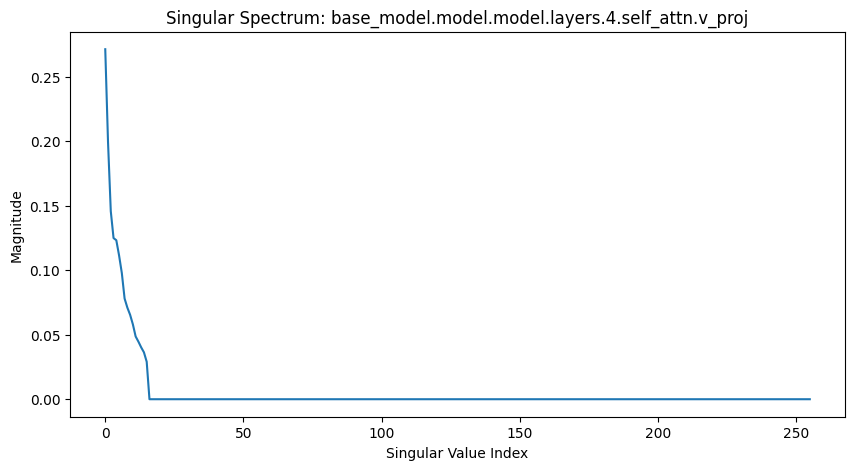

In [53]:
plt.figure(figsize=(10, 5))
plt.plot(svals1)
plt.xlabel("Singular Value Index")
plt.ylabel("Magnitude")
plt.title(f"Singular Spectrum: {layer_name}")
plt.show()

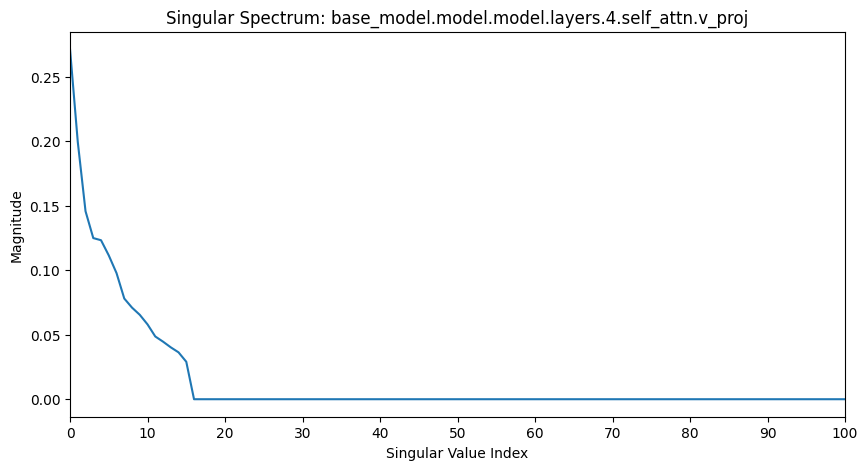

In [54]:
plt.figure(figsize=(10, 5))
plt.plot(svals1)

plt.xlabel("Singular Value Index")
plt.ylabel("Magnitude")
plt.title(f"Singular Spectrum: {layer_name}")

# set x-axis ticks every 10 up to 100
plt.xticks(np.arange(0, 101, 10))

# optional: limit x-axis range to 0–100
plt.xlim(0, 100)

plt.show()

## 4) Effective Rank Comparision

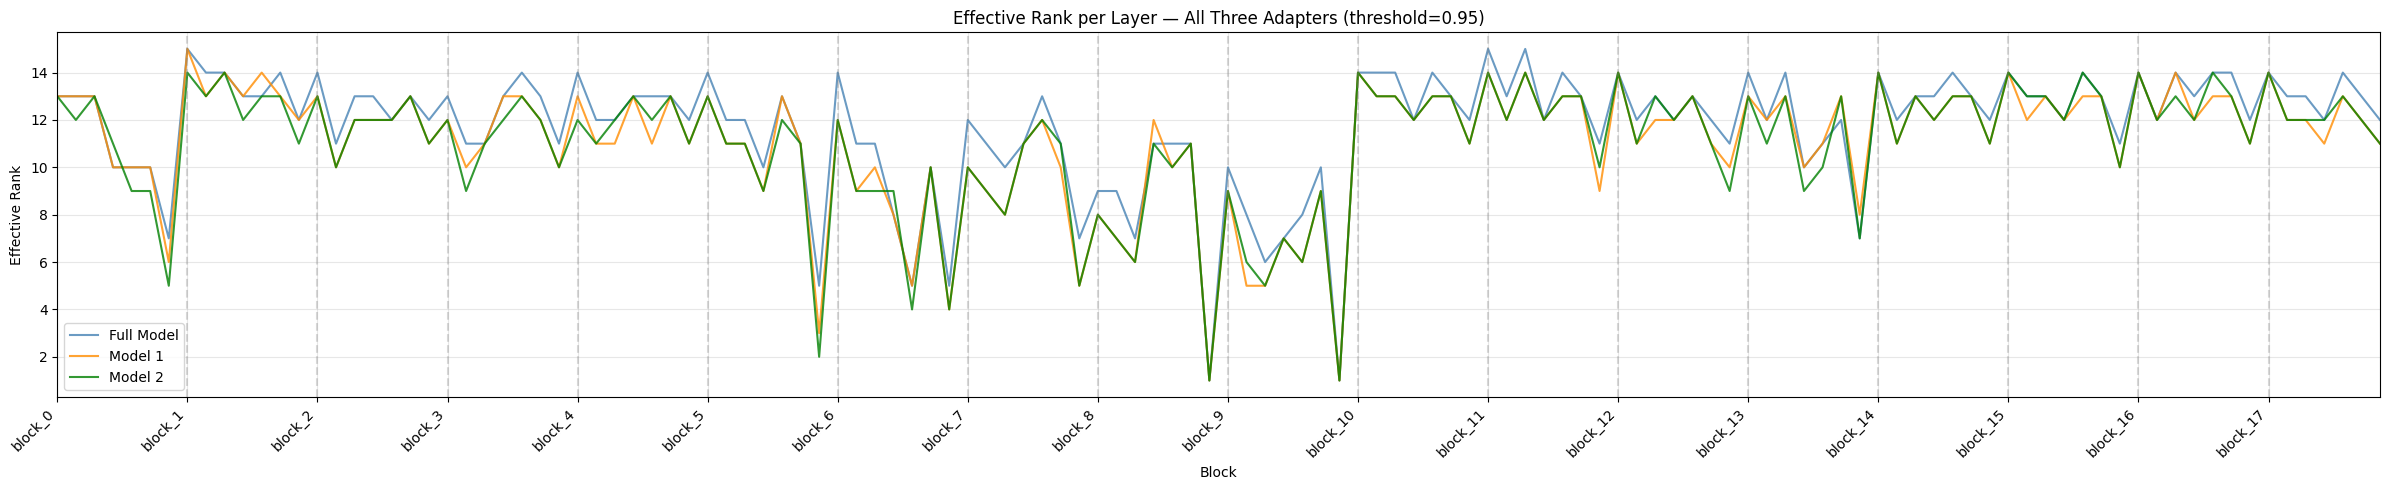

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def effective_rank(singular_values, threshold=0.95):
    energy = singular_values ** 2
    cumulative = np.cumsum(energy)
    total = cumulative[-1]
    ratio = cumulative / total
    rank = np.searchsorted(ratio, threshold) + 1
    return rank

def compute_effective_ranks(adapter_deltas, threshold=0.95):
    ranks = {}
    for layer_name, delta in adapter_deltas.items():
        _, S, _ = torch.svd(delta.float())
        S_np = S.detach().cpu().numpy()
        ranks[layer_name] = effective_rank(S_np, threshold)
    return ranks

# Compute for all three adapters
ranks_1 = compute_effective_ranks(full_model_deltas)
ranks_2 = compute_effective_ranks(model_1_deltas)
ranks_3 = compute_effective_ranks(model_2_deltas)

# Align layers
layer_names = sorted(ranks_1.keys())
r1 = [ranks_1[l] for l in layer_names]
r2 = [ranks_2[l] for l in layer_names]
r3 = [ranks_3[l] for l in layer_names]
x  = np.arange(len(layer_names))


tick_labels = [f"block_{i // 7}" for i in tick_positions]

fig, ax = plt.subplots(figsize=(24, 5))

ax.plot(x, r1, label="Full Model", alpha=0.8, color="steelblue")
ax.plot(x, r2, label="Model 1",    alpha=0.8, color="darkorange")
ax.plot(x, r3, label="Model 2",    alpha=0.8, color="green")

# Vertical lines at block boundaries
for i in tick_positions:
    ax.axvline(x=i, color="gray", linestyle="--", alpha=0.3)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")
ax.set_xlim(0, len(layer_names) - 1)

ax.set_ylabel("Effective Rank")
ax.set_xlabel("Block")
ax.set_title(f"Effective Rank per Layer — All Three Adapters (threshold=0.95)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("effective_rank_all_three_adapters.png", dpi=150)
plt.show()